# Live results — tune a filter or a binning by dragging, and watch the result follow

A quick tour of `escape`'s **lineage / live** feature, using only synthetic data from
`escape.storage.example_data`. In short:

- `filter_interactive()` / `digitize_interactive()` show a histogram with a **draggable span**
  and return the filtered / digitized `Array`.
- Everything derived from that `Array` **remembers where it came from** and which tunable
  `Param`\ s were involved.
- `res.plot(live=True)` (or `res.scan.plot(live=True)`) **redraws whenever one of those
  parameters changes** — from a dragged span, a typed number, or code.

Needs an interactive matplotlib backend — the next cell selects `ipympl` (`%matplotlib widget`).
Full description: `docs/user_guide/live.md`.

In [1]:
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

import escape
from escape import live
from escape.storage.example_data import make_pump_probe_scan

## The data

A synthetic pump-probe delay scan: detector signal `sig`, intensity reference `i0`, a boolean
`pump_on` and the per-event `delay`. All four are ordinary `escape.Array`\ s aligned by pulse ID.


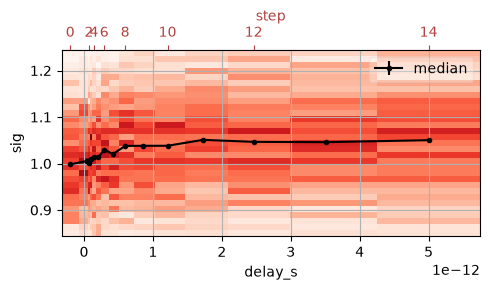

In [2]:
sig, i0, pump_on, delay = make_pump_probe_scan(seed=1)
sig.name, i0.name, delay.name = "sig", "i0", "delay"   # names show up in the parameter labels
sig

## 1 · Filter on i0 by dragging a span

`i0.filter_interactive(0.95, 1.05)` opens the histogram of `i0` with the limits `0.95 … 1.05` as a
draggable span (drag its edges, or the whole span; you can also type exact `min` / `max`).
It returns the **filtered `i0`** — so it can be used right away in an expression.

The second figure below is created by the next cell and follows the span.

HTML(value='')


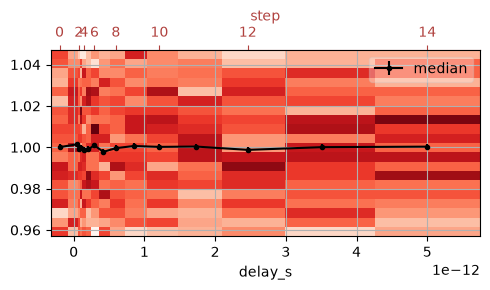

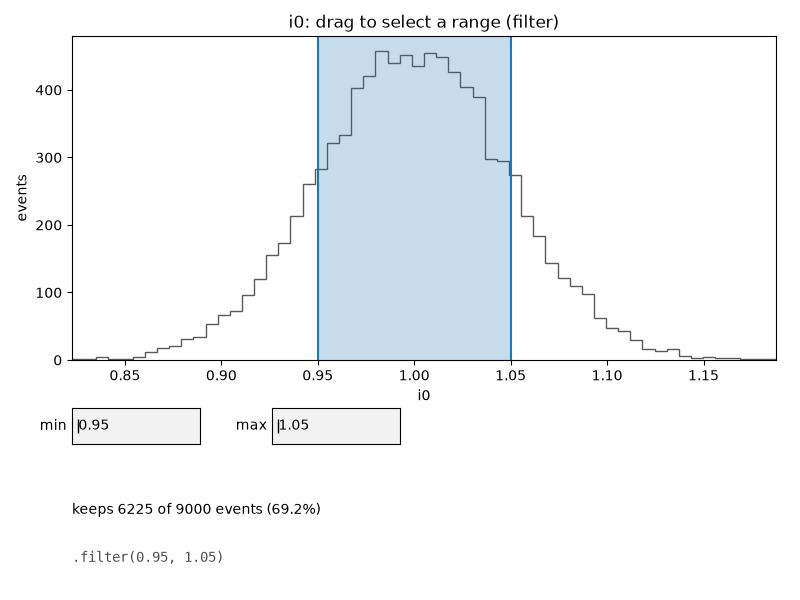

In [3]:
i0f = i0.filter_interactive(0.95, 1.05)
i0f

## 2 · A result that follows

`sig / i0f` is the intensity-normalised signal, restricted to the events that pass the filter.
`res.scan.plot(live=True)` plots the step means and **redraws whenever the span moves**
(it updates when you release the mouse button).

Go back to the `i0` histogram above and drag the limits.

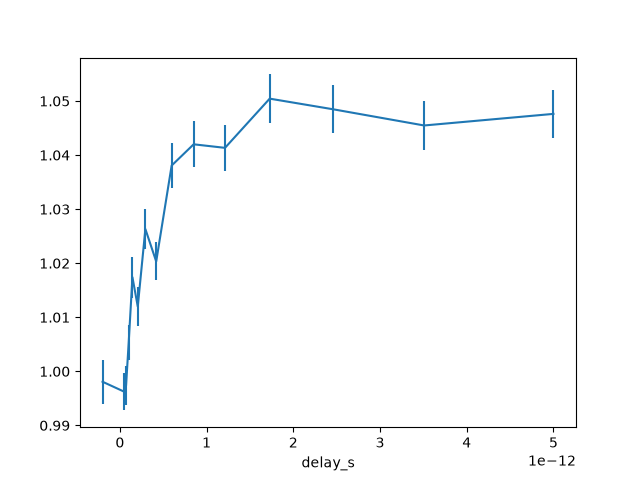

In [4]:
res = sig / i0f
lp = res.scan.plot(live=True)

### What does `res` remember?

The lineage is recorded automatically, and only because a tunable parameter is involved.
`res.params` lists every `Param` upstream; `live.describe(res)` prints the recorded chain.

In [5]:
print(live.describe(res))
res.params

truediv(sig, filter(i0, i0 min=0.8780389704995535, i0 max=0.9760349345478145))


[Param('i0 min', 0.8780389704995535), Param('i0 max', 0.9760349345478145)]

## 3 · Tune from the result instead

The parameters are shared objects, so you can also start at the *result* and edit any parameter
upstream of it. `live.panel(res)` shows them as input fields — type a value (or use a slider if
the `Param` has `bounds`), and both the plot above **and the span in the `i0` histogram** follow.

In [6]:
live.panel(res)

### Instead of dragging: the same thing from code

Setting the span is the same as dragging it. (Handy for scripted checks; skip this cell if you
want to keep your own dragged limits.)

In [7]:
tool = i0f.lineage.tool          # the histogram selector that created the parameters
tool.range = (0.98, 1.02)        # -> parameters change -> live plot redraws
print(res.params)

[Param('i0 min', 0.98), Param('i0 max', 1.02)]


In [8]:
# res.evaluate() recomputes the result with the *current* parameter values
now = res.evaluate()
print(len(res.data), "events when created ->", len(now.data), "events now")

6225 events when created -> 2829 events now


## 4 · Your own function: pass it a `Param`

Nothing here is special to `filter`. Any `escaped` function, `map_index_blocks` call or reduction
records the same way. To make your own function tunable, give it a `Param` where it takes a plain
number — the function itself just receives the number.

Here a background subtraction `x - alpha * ref`. `params="all"` puts an input field for every
parameter upstream of the result below the plot.

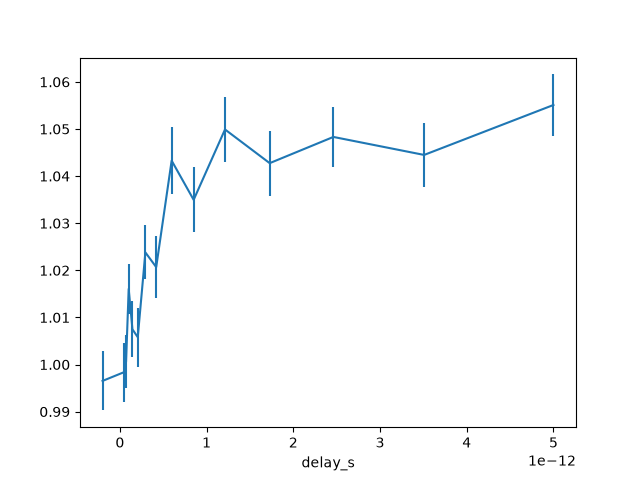

In [9]:
@escape.escaped
def subtract_background(x, ref, alpha):
    return x - alpha * ref

alpha = live.Param(0.0, "alpha", bounds=(0.0, 2.0))     # bounds -> a slider
corrected = subtract_background(sig, i0f, alpha)
lp_corr = corrected.scan.plot(live=True, params="all")

## 5 · Digitize with a draggable region and a live bin size

`delay.digitize_interactive()` shows the histogram of `delay` and lets you drag the region to bin.
Bins are set by **bin size (rounded)** — the default: edges on multiples of the size, like
`utilities.roundto` — plain **bin size**, or **number of bins**. Typing an integer such as `20`
means *number of bins*, a non-integer such as `0.5e-12` a bin size.

The digitized `delay` is then used to re-group `res` by delay (`categorize`), and that plot is live too.

HTML(value='')

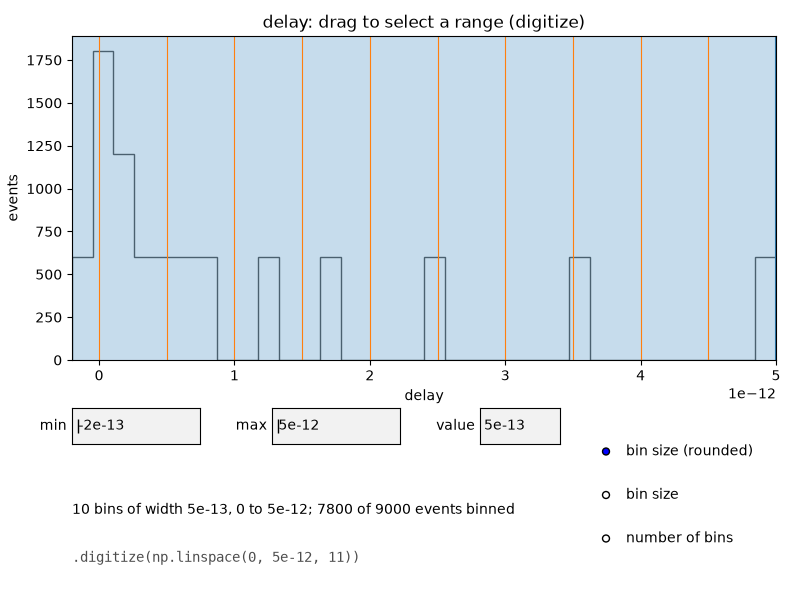

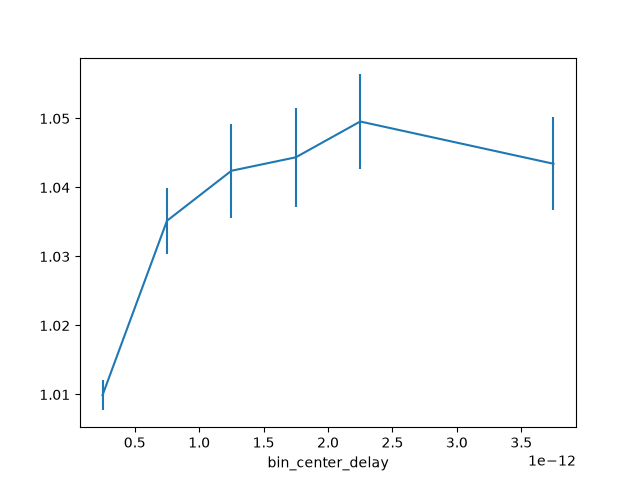

In [10]:
delay_binned = delay.digitize_interactive(n_bins=12)
binned = delay_binned.categorize(res)
lp_binned = binned.scan.plot(live=True)

## 6 · Switching it off

Recording only happens when a `Param` (or an `Array` that already has lineage) is involved, so
ordinary code pays nothing. If you ever want none of it:

```python
live.set_enabled(False)        # or  ESCAPE_LINEAGE=0  in the environment
```

Params passed to operations still work (they are replaced by their values) — results just aren't live.

In [ ]:
print("recording enabled:", live.is_enabled())
plain = sig / i0          # no Param involved -> no lineage
print("sig / i0 has lineage:", plain.lineage is not None)

## Notes and current limits

- Only results that are `Array`\ s carry lineage. Reductions to plain numbers (e.g. `nanmean()`
  over events) don't; make any drawing function live with
  `live.live_plot(res, lambda ax, a: ax.plot(a.nanmean()))`.
- A recorded chain keeps its intermediate results in memory — meant for data that fits.
- Live plots clear and redraw their axes, so zoom resets on each update.
- The digitize tool writes its bins to the parameter but doesn't follow external changes of it.